<a href="https://colab.research.google.com/github/raissabarb/cn/blob/main/Atividade_3_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade 3 - Cálculo Numérico**


*   Isabela Cristina
*   Raissa Barbosa



# Funções para investigar: bisseção, Newton e secante

Neste notebook cada método numérico é implementado em uma função independente (`bissecao`, `newton` e `secante`), seguindo o modelo apresentado em aula. Todas as funções usam **tol = 10⁻⁶** e **máximo de 100 iterações** e retornam:

- a aproximação final da raiz;
- o número de iterações realizadas;
- o histórico (lista com as aproximações de cada iteração);
- um texto indicando convergência ou o motivo da falha.

## Critério de parada adotado

Foram usados os **dois critérios** sugeridos no enunciado:

1. **Resíduo:** `|f(x_k)| ≤ tol`. É o critério principal: se ele for satisfeito, o método é considerado **convergido**.
2. **Diferença entre aproximações sucessivas:** `|x_{k+1} − x_k| ≤ tol·max(1, |x_{k+1}|)` (tolerância relativa, como no modelo). Se o passo ficar pequeno, no **Newton e na secante** o resíduo é verificado: se estiver pequeno, convergiu; se não, o método **para com aviso** ("passo pequeno, mas resíduo ainda alto"), pois isso indica estagnação e não uma raiz. Na **bisseção**, como a raiz fica sempre presa no intervalo `[a, b]`, um passo menor que a tolerância já garante que o erro é menor que `tol`, então isso também conta como convergência.

Além disso, cada método detecta situações em que não é possível continuar:

- **Bisseção:** `f(a)·f(b) > 0` (não há garantia de raiz no intervalo);
- **Newton:** `|f'(x_k)|` nulo ou muito pequeno (≤ 10⁻¹⁴);
- **Secante:** denominador `f(x_k) − f(x_{k-1})` nulo ou muito pequeno (≤ 10⁻¹⁴);
- **Todos:** máximo de 100 iterações atingido sem convergência.

In [26]:
import math
import pandas as pd
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from IPython.display import Image, display

TOL = 1e-6
MAX_ITER = 100

## Funções e derivadas

As derivadas são necessárias apenas para o método de Newton.

In [27]:
def f1(x):  return x**2 - 2
def df1(x): return 2*x

def f2(x):  return x**3 - x - 2
def df2(x): return 3*x**2 - 1

def f3(x):  return math.exp(-x) - x
def df3(x): return -math.exp(-x) - 1

def f4(x):  return x**3 - 2*x + 2
def df4(x): return 3*x**2 - 2

## Método da bisseção

In [28]:
def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):

    a, b = float(a), float(b)
    historico = []
    fa, fb = f(a), f(b)

    # Sem mudança de sinal não há garantia de raiz em [a, b].
    if fa * fb > 0:
        return float("nan"), 0, historico, "Falhou: f(a)f(b) > 0, sem garantia de raiz no intervalo"

    c_ant = None
    for k in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        historico.append({"k": k, "a": a, "b": b, "x": c, "f(x)": fc})

        if abs(fc) <= tol:
            return c, k + 1, historico, "Convergiu pelo resíduo"

        # Na bisseção a raiz está sempre dentro de [a, b]; se o passo já é
        # menor que a tolerância, o erro da aproximação também é.
        if c_ant is not None and abs(c - c_ant) <= tol * max(1.0, abs(c)):
            return c, k + 1, historico, "CConvergiu pela diferença entre aproximações sucessivas"

        # Mantém o subintervalo onde há mudança de sinal.
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
        c_ant = c

    return c, max_iter, historico, "Parou: atingiu o máximo de iterações"

## Método de Newton

Estrutura mantida igual à do modelo; a única mudança é que a função também retorna o número de iterações.

In [29]:
def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER, deriv_tol=1e-14):

    x = float(x0)
    historico = []

    for k in range(max_iter):
        fx = f(x)
        dfx = df(x)
        historico.append({"k": k, "x": x, "f(x)": fx, "f'(x)": dfx})

        if abs(fx) <= tol:
            return x, k, historico, "Convergiu pelo resíduo"

        if abs(dfx) <= deriv_tol:
            return x, k, historico, "Parou: derivada nula ou muito pequena"

        x_novo = x - fx / dfx

        # Um passo pequeno sem resíduo pequeno pode indicar estagnação.
        if abs(x_novo - x) <= tol * max(1.0, abs(x_novo)):
            x = x_novo
            if abs(f(x)) <= tol:
                historico.append({"k": k + 1, "x": x, "f(x)": f(x), "f'(x)": df(x)})
                return x, k + 1, historico, "Convergiu pelo resíduo após passo pequeno"
            return x, k + 1, historico, "Parou: passo pequeno, mas resíduo ainda alto"

        x = x_novo

    return x, max_iter, historico, "Prou: atingiu o máximo de iterações"

## Método da secante

In [30]:
def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER, den_tol=1e-14):

    x0, x1 = float(x0), float(x1)
    f0, f1_ = f(x0), f(x1)
    historico = [{"k": 0, "x": x0, "f(x)": f0}, {"k": 1, "x": x1, "f(x)": f1_}]

    if abs(f0) <= tol:
        return x0, 0, historico, "Convergiu pelo resíduo"
    if abs(f1_) <= tol:
        return x1, 0, historico, "Convergiu pelo resíduo"

    for k in range(1, max_iter + 1):
        den = f1_ - f0
        if abs(den) <= den_tol:
            return x1, k - 1, historico, "Parou: denominador nulo ou muito pequeno"

        x2 = x1 - f1_ * (x1 - x0) / den
        f2_ = f(x2)
        historico.append({"k": k + 1, "x": x2, "f(x)": f2_})

        if abs(f2_) <= tol:
            return x2, k, historico, "Convergiu pelo resíduo"

        # Um passo pequeno sem resíduo pequeno pode indicar estagnação.
        if abs(x2 - x1) <= tol * max(1.0, abs(x2)):
            return x2, k, historico, "Parou: passo pequeno, mas resíduo ainda alto"

        x0, f0 = x1, f1_
        x1, f1_ = x2, f2_

    return x1, max_iter, historico, "Parou: atingiu o máximo de iterações"

## Tabela de resultados

Os valores iniciais são os sugeridos no enunciado (bisseção: intervalo; Newton: $x_0$; secante: $(x_0, x_1)$).

In [31]:
funcoes = {
    "f1(x) = x² − 2":       (f1, df1, (1, 2),   1.5, (1, 2)),
    "f2(x) = x³ − x − 2":   (f2, df2, (1, 2),   1.5, (1, 2)),
    "f3(x) = e^(−x) − x":   (f3, df3, (0, 1),   0.5, (0, 1)),
    "f4(x) = x³ − 2x + 2":  (f4, df4, (-2, -1), -2,  (-2, -1)),
}

def linha(nome, metodo, valores, resultado, f):
    raiz, n_iter, _, estado = resultado
    return {
        "Função": nome,
        "Método": metodo,
        "Valores iniciais": valores,
        "Raiz aproximada": raiz,
        "|f(x)| final": abs(f(raiz)) if not math.isnan(raiz) else float("nan"),
        "Iterações/resultado": f"{n_iter} — {estado}",
    }

linhas = []
for nome, (f, df, (a, b), x0, (s0, s1)) in funcoes.items():
    linhas.append(linha(nome, "Bisseção", f"[{a}, {b}]", bissecao(f, a, b, TOL, MAX_ITER), f))
    linhas.append(linha(nome, "Newton",   f"x0 = {x0}",   newton(f, df, x0, TOL, MAX_ITER), f))
    linhas.append(linha(nome, "Secante",  f"({s0}, {s1})", secante(f, s0, s1, TOL, MAX_ITER), f))

tabela = pd.DataFrame(linhas)
tabela.style.format({"Raiz aproximada": "{:.8f}", "|f(x)| final": "{:.2e}"})

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² − 2,Bisseção,"[1, 2]",1.41421413,1.62e-06,20 — CConvergiu pela diferença entre aproximações sucessivas
1,f1(x) = x² − 2,Newton,x0 = 1.5,1.41421356,4.51e-12,3 — Convergiu pelo resíduo
2,f1(x) = x² − 2,Secante,"(1, 2)",1.41421356,8.93e-10,5 — Convergiu pelo resíduo
3,f2(x) = x³ − x − 2,Bisseção,"[1, 2]",1.52138042,4.27e-06,20 — CConvergiu pela diferença entre aproximações sucessivas
4,f2(x) = x³ − x − 2,Newton,x0 = 1.5,1.52137981,5.89e-07,2 — Convergiu pelo resíduo
5,f2(x) = x³ − x − 2,Secante,"(1, 2)",1.52137971,7.02e-09,6 — Convergiu pelo resíduo
6,f3(x) = e^(−x) − x,Bisseção,"[0, 1]",0.56714344,2.35e-07,20 — Convergiu pelo resíduo
7,f3(x) = e^(−x) − x,Newton,x0 = 0.5,0.56714317,1.96e-07,2 — Convergiu pelo resíduo
8,f3(x) = e^(−x) − x,Secante,"(0, 1)",0.56714331,2.54e-08,4 — Convergiu pelo resíduo
9,f4(x) = x³ − 2x + 2,Bisseção,"[-2, -1]",-1.76929188,3.52e-06,20 — CConvergiu pela diferença entre aproximações sucessivas


## Testes das situações de falha

Aqui verificamos se o código detecta os casos em que não é possível continuar.

In [32]:
testes = []

# Bisseção: f(a)f(b) > 0  (f1 em [0, 1]: f(0) = -2 e f(1) = -1, mesmo sinal)
testes.append(linha("f1(x) = x² − 2", "Bisseção", "[0, 1]", bissecao(f1, 0, 1, TOL, MAX_ITER), f))

# Newton: derivada nula  (f1'(0) = 0)
testes.append(linha("f1(x) = x² − 2", "Newton", "x0 = 0", newton(f1, df1, 0, TOL, MAX_ITER), f))

# Secante: denominador nulo  (x0 = x1)
testes.append(linha("f1(x) = x² − 2", "Secante", "(1, 1)", secante(f1, 1, 1, TOL, MAX_ITER), f))

# Newton sem convergência: f4 com x0 = 0 entra em ciclo 0 -> 1 -> 0 -> ...
def _linha_f4(nome, metodo, valores, res):
    raiz, n_iter, _, estado = res
    return {"Função": nome, "Método": metodo, "Valores iniciais": valores,
            "Raiz aproximada": raiz, "|f(x)| final": abs(f4(raiz)),
            "Iterações/resultado": f"{n_iter} — {estado}"}
testes.append(_linha_f4("f4(x) = x³ − 2x + 2", "Newton", "x0 = 0", newton(f4, df4, 0, TOL, MAX_ITER)))

pd.DataFrame(testes).style.format({"Raiz aproximada": "{:.8f}", "|f(x)| final": "{:.2e}"})

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² − 2,Bisseção,"[0, 1]",nan,nan,"0 — Falhou: f(a)f(b) > 0, sem garantia de raiz no intervalo"
1,f1(x) = x² − 2,Newton,x0 = 0,0.00000000,2.00e+00,0 — Parou: derivada nula ou muito pequena
2,f1(x) = x² − 2,Secante,"(1, 1)",1.00000000,1.00e+00,0 — Parou: denominador nulo ou muito pequeno
3,f4(x) = x³ − 2x + 2,Newton,x0 = 0,0.00000000,2.00e+00,100 — Prou: atingiu o máximo de iterações


## Animações

Cada animação mostra o gráfico de $f(x)$, o eixo $y=0$, os pontos gerados pelo método, os segmentos/retas usados para calcular a próxima aproximação, o número da iteração, o valor atual da aproximação e o resíduo $|f(x_k)|$. Os GIFs são salvos na pasta do notebook.

- **Bisseção:** o intervalo $[a,b]$ (em laranja) que contém a raiz e a sua redução a cada iteração; o ponto vermelho é o ponto médio.
- **Newton:** a reta tangente em $(x_k, f(x_k))$; onde ela cruza o eixo horizontal está $x_{k+1}$ (quadrado verde).
- **Secante:** a reta que passa pelos dois últimos pontos; onde ela cruza o eixo horizontal está $x_{k+1}$ (quadrado verde).

In [33]:
def _base(ax, f, xlim, titulo):
    """Desenha f(x), o eixo y = 0 e configura os limites do gráfico."""
    xs = np.linspace(xlim[0], xlim[1], 400)
    ys = np.array([f(x) for x in xs])
    ax.plot(xs, ys, color="tab:blue", lw=2, label="f(x)")
    ax.axhline(0, color="black", lw=1)
    margem = 0.15 * (ys.max() - ys.min())
    ax.set_xlim(*xlim)
    ax.set_ylim(ys.min() - margem, ys.max() + margem)
    ax.set_title(titulo)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(alpha=0.3)

def _info(ax, texto):
    ax.text(0.02, 0.97, texto, transform=ax.transAxes, va="top", family="monospace",
            fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

def _salvar(fig, draw, n_frames, arquivo):
    frames = list(range(n_frames)) + [n_frames - 1] * 2   # segura o último quadro
    ani = FuncAnimation(fig, draw, frames=frames, interval=1000)
    ani.save(arquivo, writer=PillowWriter(fps=1))
    plt.close(fig)
    return arquivo

def animar_bissecao(f, hist, xlim, titulo, arquivo):
    fig, ax = plt.subplots(figsize=(8, 5))
    def draw(i):
        ax.clear()
        _base(ax, f, xlim, titulo)
        h = hist[i]
        a, b, c, fc = h["a"], h["b"], h["x"], h["f(x)"]
        ax.axvspan(a, b, color="orange", alpha=0.25, label="intervalo [a, b]")
        ax.plot([a, b], [0, 0], color="orange", lw=6)
        for p in (a, b):
            ax.plot([p, p], [0, f(p)], "--", color="gray")
            ax.plot(p, f(p), "o", color="gray")
        ax.plot([hh["x"] for hh in hist[:i]], [hh["f(x)"] for hh in hist[:i]],
                "o", color="lightcoral", ms=4, label="pontos médios anteriores")
        ax.plot([c, c], [0, fc], "r:")
        ax.plot(c, fc, "ro", ms=8, label="ponto médio atual")
        _info(ax, f"iteração : {h['k'] + 1}\nx (médio)  : {c:.8f}\n|f(x)|     : {abs(fc):.2e}\n"
                  f"largura b-a: {b - a:.2e}")
        ax.legend(loc="lower right", fontsize=8)
    return _salvar(fig, draw, len(hist), arquivo)

def animar_newton(f, hist, xlim, titulo, arquivo):
    fig, ax = plt.subplots(figsize=(8, 5))
    def draw(i):
        ax.clear()
        _base(ax, f, xlim, titulo)
        h = hist[i]
        x, fx, dfx = h["x"], h["f(x)"], h["f'(x)"]
        ax.plot([hh["x"] for hh in hist[:i]], [hh["f(x)"] for hh in hist[:i]],
                "o", color="lightcoral", ms=4, label="aproximações anteriores")
        ax.plot([x, x], [0, fx], "r:")
        ax.plot(x, fx, "ro", ms=8, label="x_k atual")
        if i + 1 < len(hist):                       # há próximo passo: desenha a tangente
            xt = np.array(xlim)
            ax.plot(xt, fx + dfx * (xt - x), color="green", label="reta tangente")
            x_novo = hist[i + 1]["x"]
            ax.plot(x_novo, 0, "s", color="green", ms=8, label="x(k+1)")
            status = f"x_(k+1)   : {x_novo:.8f}"
        else:
            status = "convergiu / fim"
        _info(ax, f"iteração : {h['k']}\nx_k        : {x:.8f}\n|f(x_k)|   : {abs(fx):.2e}\n{status}")
        ax.legend(loc="lower right", fontsize=8)
    return _salvar(fig, draw, len(hist), arquivo)

def animar_secante(f, hist, xlim, titulo, arquivo):
    fig, ax = plt.subplots(figsize=(8, 5))
    n = len(hist) - 2                                # cada passo usa 3 pontos do histórico
    def draw(i):
        ax.clear()
        _base(ax, f, xlim, titulo)
        p0, p1, p2 = hist[i], hist[i + 1], hist[i + 2]
        ax.plot([hh["x"] for hh in hist[:i]], [hh["f(x)"] for hh in hist[:i]],
                "o", color="lightcoral", ms=4, label="aproximações anteriores")
        ax.plot([p0["x"], p1["x"]], [p0["f(x)"], p1["f(x)"]], "ro", ms=8, label="x(k-1), x(k)")
        xt = np.array(xlim)
        m = (p1["f(x)"] - p0["f(x)"]) / (p1["x"] - p0["x"])
        ax.plot(xt, p1["f(x)"] + m * (xt - p1["x"]), color="green", label="reta secante")
        ax.plot(p2["x"], 0, "s", color="green", ms=8, label="x(k+1)")
        ax.plot([p2["x"], p2["x"]], [0, p2["f(x)"]], "g:")
        _info(ax, f"iteração : {p2['k'] - 1}\nx_(k+1)    : {p2['x']:.8f}\n|f(x_(k+1))|: {abs(p2['f(x)']):.2e}")
        ax.legend(loc="lower right", fontsize=8)
    return _salvar(fig, draw, n, arquivo)

### Combinações escolhidas

1. Bisseção — $f_1(x)=x^2-2$ em $[1,2]$
2. Newton — $f_4(x)=x^3-2x+2$ com $x_0=-2$
3. Secante — $f_2(x)=x^3-x-2$ com $(x_0,x_1)=(1,2)$
4. (extra) Newton — $f_4$ com $x_0=0$, onde o método **não converge** (entra em ciclo $0\to1\to0$).

anim_bissecao_f1.gif
anim_newton_f4.gif
anim_secante_f2.gif
anim_newton_f4_ciclo.gif


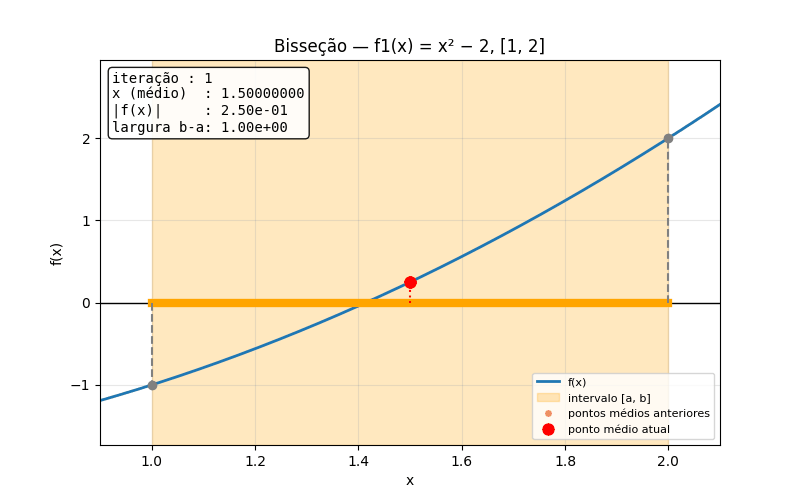

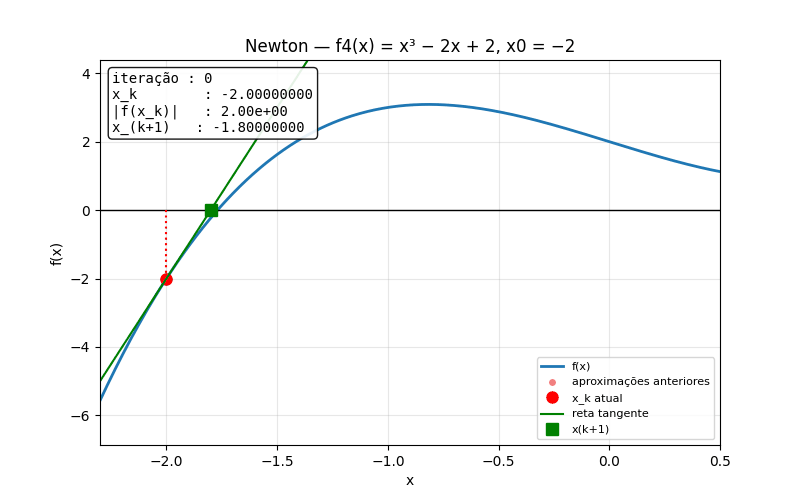

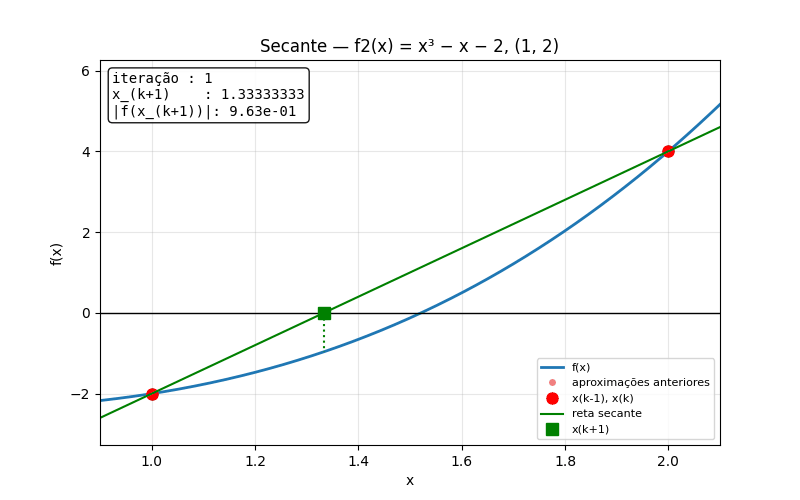

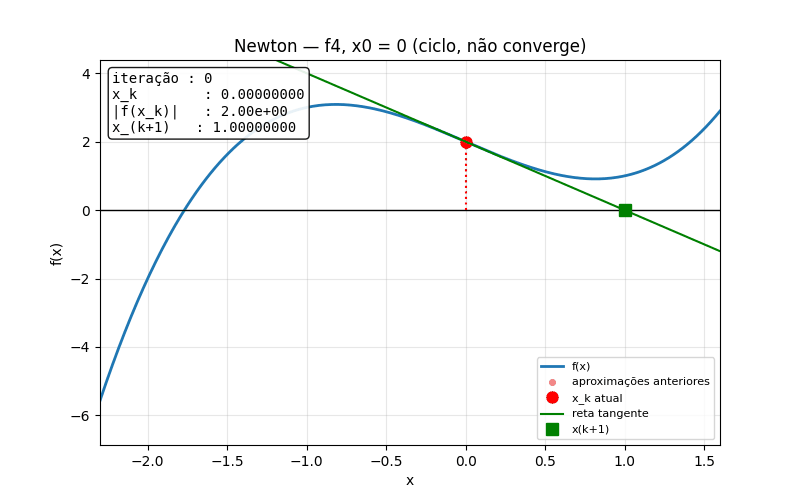

In [34]:
_, _, h, _ = bissecao(f1, 1, 2, TOL, MAX_ITER)
g1 = animar_bissecao(f1, h, (0.9, 2.1), "Bisseção — f1(x) = x² − 2, [1, 2]", "anim_bissecao_f1.gif")

_, _, h, _ = newton(f4, df4, -2, TOL, MAX_ITER)
g2 = animar_newton(f4, h, (-2.3, 0.5), "Newton — f4(x) = x³ − 2x + 2, x0 = −2", "anim_newton_f4.gif")

_, _, h, _ = secante(f2, 1, 2, TOL, MAX_ITER)
g3 = animar_secante(f2, h, (0.9, 2.1), "Secante — f2(x) = x³ − x − 2, (1, 2)", "anim_secante_f2.gif")

_, _, h, _ = newton(f4, df4, 0, TOL, 8)   # só as 8 primeiras iterações (ciclo)
g4 = animar_newton(f4, h, (-2.3, 1.6), "Newton — f4, x0 = 0 (ciclo, não converge)", "anim_newton_f4_ciclo.gif")

for g in (g1, g2, g3, g4):
    print(g)
display(Image(filename=g1)); display(Image(filename=g2)); display(Image(filename=g3)); display(Image(filename=g4))

## Tabela de resultados como imagem

Usada no dashboard (Mathcha) e para conferência.

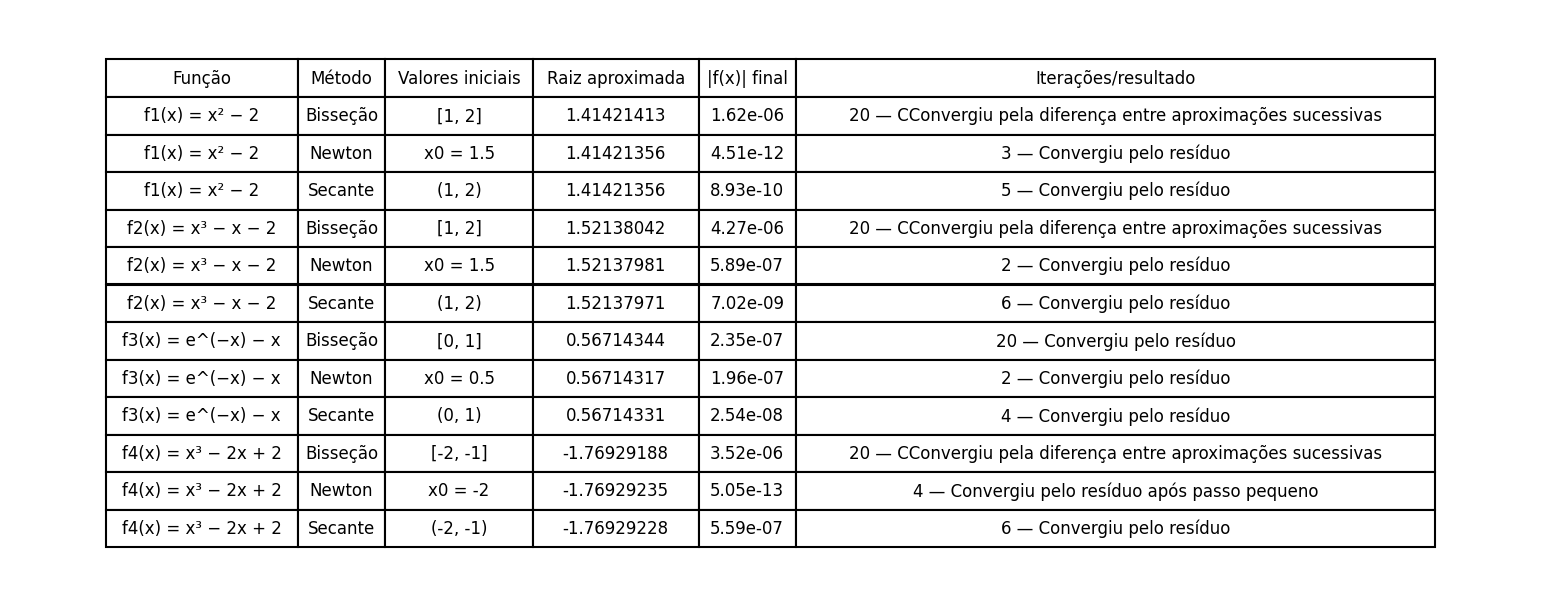

In [35]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")
cols = list(tabela.columns)
dados = [[r["Função"], r["Método"], r["Valores iniciais"], f"{r['Raiz aproximada']:.8f}",
          f"{r['|f(x)| final']:.2e}", r["Iterações/resultado"]] for _, r in tabela.iterrows()]
t = ax.table(cellText=dados, colLabels=cols, loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1, 1.5)
t.auto_set_column_width(list(range(len(cols))))
plt.savefig("tabela_resultados.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename="tabela_resultados.png"))

## Conclusões

- Nos casos sugeridos, os três métodos convergiram para as raízes esperadas (por exemplo, $\sqrt{2}\approx 1{,}41421$ para $f_1$ e ≈ −1,76929 para $f_4$), com resíduo abaixo de $10^{-6}$.
- Newton e secante precisaram de bem menos iterações que a bisseção, que tem convergência mais lenta (o intervalo cai pela metade a cada passo), mas é a mais segura, pois sempre converge se houver mudança de sinal.
- Os testes de falha mostram que o código detecta: intervalo sem mudança de sinal, derivada nula, denominador nulo e falta de convergência dentro de 100 iterações (Newton em $f_4$ com $x_0=0$ entra em ciclo).
- Critério adotado: resíduo $|f(x_k)|\le 10^{-6}$ como condição de convergência, com verificação adicional do tamanho do passo $|x_{k+1}-x_k|$ para detectar estagnação.